# 종합: 8×8 Snake DQN

탐험(eps0)·표현(GAP)·보상(step) 세 축으로 baseline 9.8 → 37.3

In [5]:
import numpy as np, os
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def load_scores(run_name):
    return np.load(f'results/{run_name}/history.npz')['scores']

def moving_avg(scores, window=50):
    return np.array([np.mean(scores[max(0, i-window+1):i+1]) for i in range(len(scores))])

def final_score(run_name):
    return float(np.mean(load_scores(run_name)[-300:]))

## 1. 보상 그리드 서치 (eps0+GAP 고정, food=+10)
death {-10,-12,-14} × step {-0.1,-0.25,-0.5}, 총 9개 config의 학습 곡선.


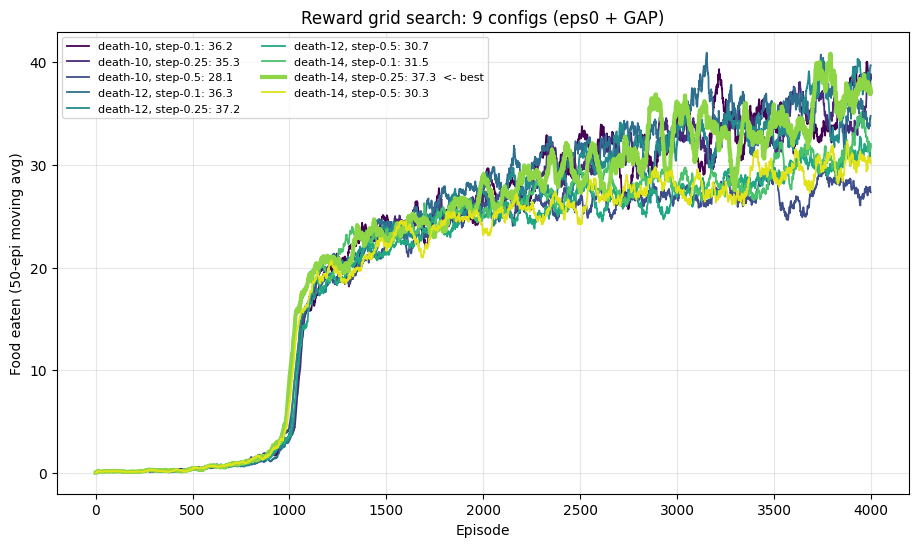

In [6]:
# 그리드 9개: eps0+GAP·food10 고정, death×step만 변형
DEATHS = [10, 12, 14]
STEPS  = [0.1, 0.25, 0.5]
grid_runs = [f'gs2_d{d}_s{s}' for d in DEATHS for s in STEPS]
best_run  = 'gs2_d14_s0.25'

plt.figure(figsize=(11, 6))
palette = cm.viridis(np.linspace(0, 0.95, len(grid_runs)))

for run_name, color in zip(grid_runs, palette):
    scores  = load_scores(run_name)
    is_best = (run_name == best_run)
    _, d_part, s_part = run_name.split('_')
    label = f'death-{d_part[1:]}, step-{s_part[1:]}: {final_score(run_name):.1f}'
    plt.plot(moving_avg(scores), color=color,
             linewidth=(3 if is_best else 1.3),
             label=label + ('  <- best' if is_best else ''))

plt.xlabel('Episode'); plt.ylabel('Food eaten (50-epi moving avg)')
plt.title('Reward grid search: 9 configs (eps0 + GAP)')
plt.legend(loc='upper left', fontsize=8, ncol=2); plt.grid(alpha=0.3)
plt.show()

## 2. Heatmap (death × step)

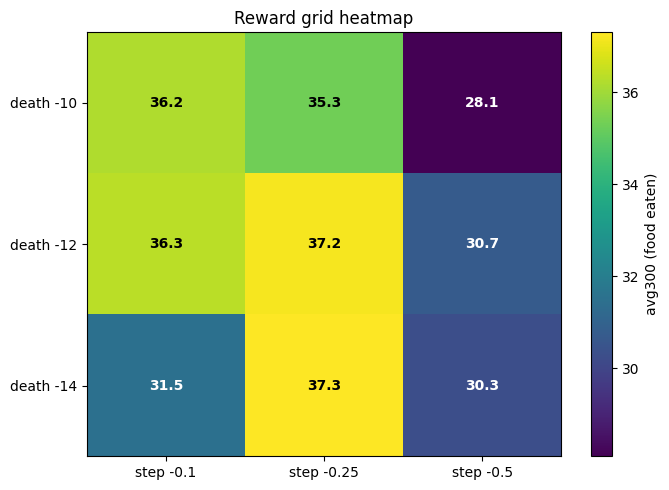

In [7]:
# death(행) × step(열) 최종 점수 행렬
score_matrix = np.array([
    [final_score(f'gs2_d{d}_s{s}') for s in STEPS]
    for d in DEATHS
])

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(score_matrix, cmap='viridis', aspect='auto')
ax.set_xticks(range(len(STEPS)));  ax.set_xticklabels([f'step -{s}' for s in STEPS])
ax.set_yticks(range(len(DEATHS))); ax.set_yticklabels([f'death -{d}' for d in DEATHS])

for i in range(len(DEATHS)):
    for j in range(len(STEPS)):
        value = score_matrix[i, j]
        ax.text(j, i, f'{value:.1f}', ha='center', va='center',
                color=('black' if value >= 34 else 'white'), fontweight='bold')

plt.colorbar(im, label='avg300 (food eaten)')
ax.set_title('Reward grid heatmap')
plt.tight_layout(); plt.show()


## 3. Ablation (탐험 × 표현 + best 보상)
탐험 ablation 4개에 그리드 best 1개를 추가

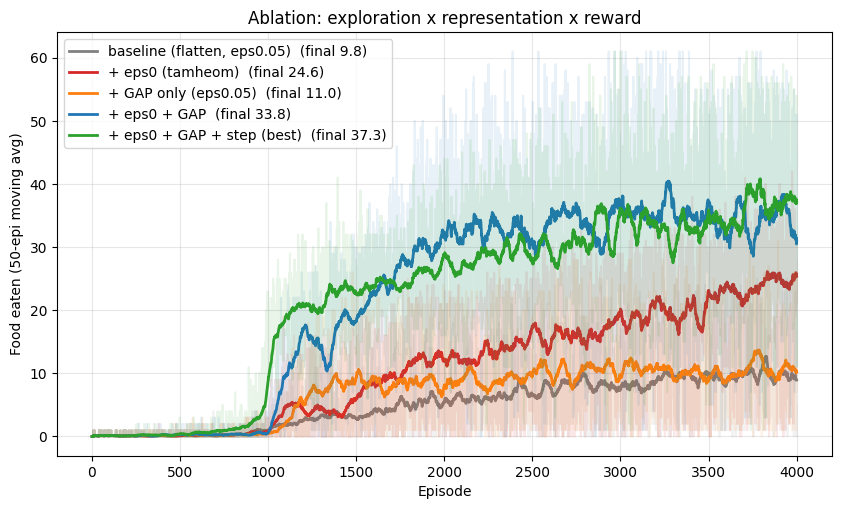

In [8]:
ablation_runs = [
    ('baseline (flatten, eps0.05)', 'baseline_15k',  'gray'),
    ('+ eps0 (tamheom)',            'cnn_eps0_only', 'tab:red'),
    ('+ GAP only (eps0.05)',        'cnn_gap_only',  'tab:orange'),
    ('+ eps0 + GAP',                'eps0_gap',      'tab:blue'),
    ('+ eps0 + GAP + step (best)',  'gs2_d14_s0.25', 'tab:green'),
]

plt.figure(figsize=(10, 5.5))
for label, run_name, color in ablation_runs:
    scores   = load_scores(run_name)
    episodes = np.arange(1, len(scores) + 1)
    plt.plot(episodes, scores,             color=color, alpha=0.10)    # 원본 (연하게)
    plt.plot(episodes, moving_avg(scores), color=color, linewidth=2,   # 이동평균 (진하게)
             label=f'{label}  (final {final_score(run_name):.1f})')

plt.xlabel('Episode'); plt.ylabel('Food eaten (50-epi moving avg)')
plt.title('Ablation: exploration x representation x reward')
plt.legend(loc='upper left'); plt.grid(alpha=0.3)
plt.show()


## 4. 최종

만점 = 보드를 꽉 채우는 완벽한 게임 도달

![best policy](figs/grid_best_perfect.gif)


## 5. 한계와 향후 방향

### 한계

- **단일 환경 검증**: 8×8 고정 보드·단일 먹이에서만 실험했다. 보드 크기나 먹이 수가 바뀌었을 때의 일반화는 확인하지 못했다.
- **수렴 미완**: 4000 에피소드에서도 학습 곡선이 우상향 중이라 성능 수렴을 끝까지 보지는 못했다(CPU·시간 제약). 다만 **만점(61)을 달성**했으므로 "완벽한 게임이 가능하다"는 것 자체는 입증되었다.
- **높은 분산**: 먹이가 매 게임 무작위로 배치되어 점수 분산이 크다.

### 향후 방향
- **수렴까지 학습**: 우상향하는 곡선이 어디서 멈추는지 확인.
- **replay buffer 우선순위 샘플링**: 현재 replay buffer는 무작위로 샘플링한다. prioritized sweeping의 개념(TD 오차가 큰 전이를 우선 업데이트)을 차용해 replay buffer에서 우선순위로 샘플링하면, 학습이 더 필요한 경험에 업데이트를 집중해 학습 효율을 높일 수 있다.
